In [2]:
# 1. Importy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# 2. Wczytaj dane pogodynki
df = pd.read_csv("C:\ML-danych-pogodowych\data\pogodynka_zbilansowana.csv")

# 3. Stwórz zmienną docelową (kategoryzacja opadu)
def opad_kategoria(x):
    if x == 0:
        return 0  # brak
    elif x < 1:
        return 1  # słaby
    elif x < 3:
        return 2  # średni
    else:
        return 3  # silny

df['Opad_kat'] = df['Opad'].apply(opad_kategoria)

# 4. Wybór zmiennych
X = df.drop(columns=['Opad', 'Opad_kat', 'iddepeszy', 'Kategoria'])
y = df['Opad_kat']

# 5. Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 6. Wczytanie modeli
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# 7. Trening i ewaluacja
results = []
conf_matrices = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    })

    conf_matrices[name] = confusion_matrix(y_test, y_pred)

# 8. Wyniki w tabeli
results_df = pd.DataFrame(results)
display(results_df)


C:\Users\Rafal Karpowicz\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:13:12] WARNING: D:\bld\xgboost-split_1737531311373\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.877848,0.875355,0.877848,0.871267
1,XGBoost,0.869295,0.864977,0.869295,0.865011
2,KNN,0.783027,0.760084,0.783027,0.760751


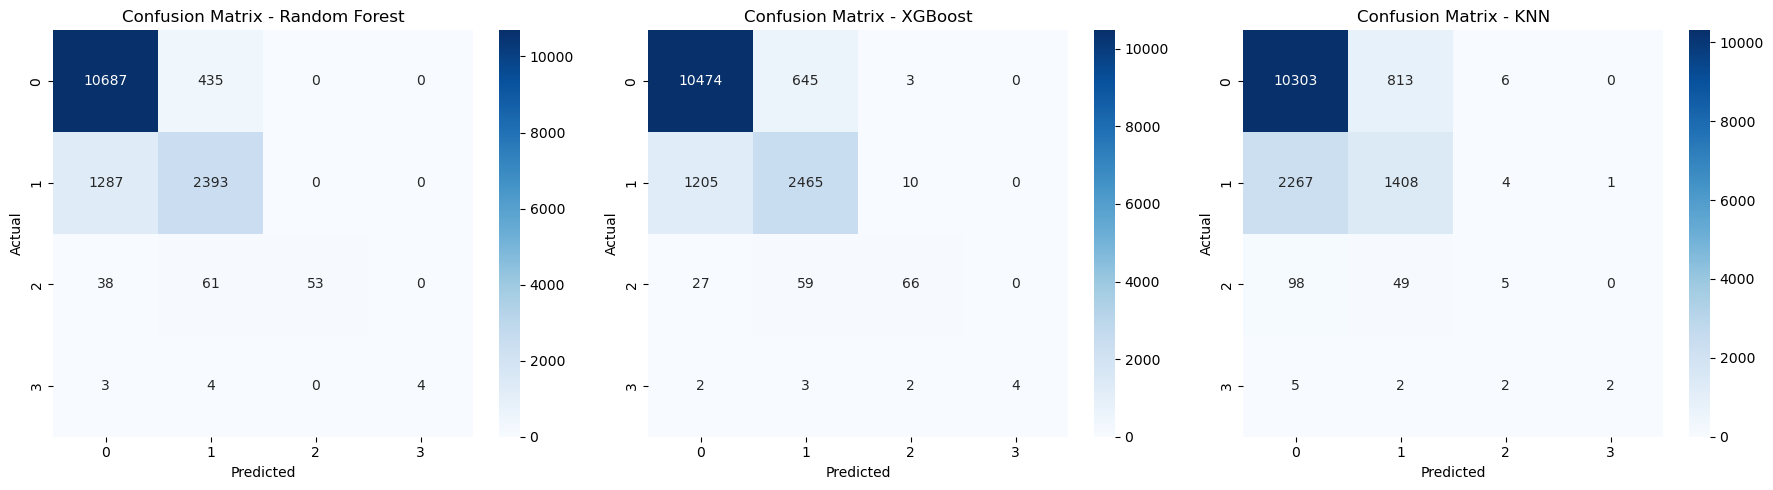

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, cm) in enumerate(conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"Confusion Matrix - {name}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()


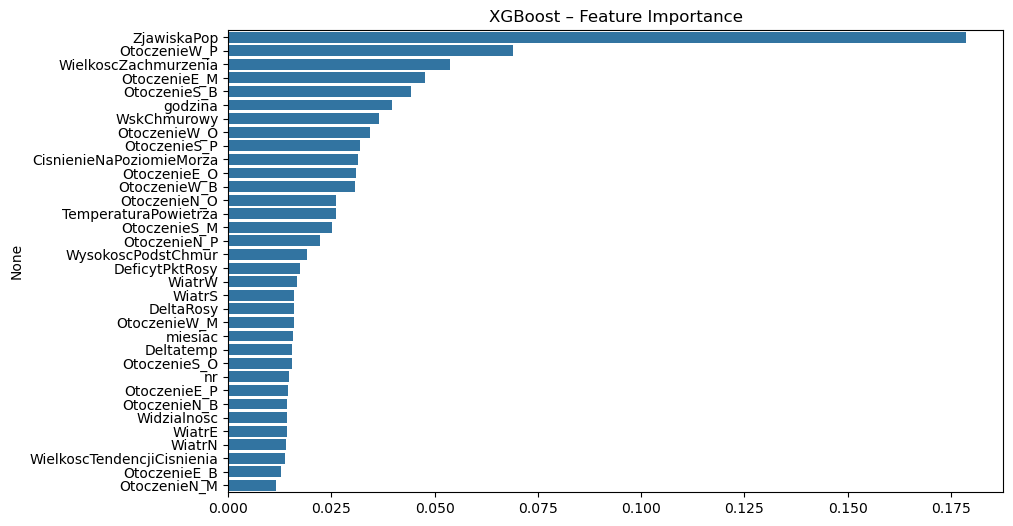

In [4]:
# Feature importance z XGBoost
xgb_model = models['XGBoost']
importance = xgb_model.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("XGBoost – Feature Importance")
plt.show()
